In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

rng = np.random.default_rng(42)

## Vanila-DeepONet

-, Step 1: load data \
-, Step 2: Training \
-, Step 3: Test performance & Tracking

#### Step 1: Load data

In [3]:
def plotting_impluse_action_potential(t, v, I_stim, T):
    fig, ax = plt.subplots(3,1, figsize=(8, 8))
    ax[0].plot(t, v)
    ax[0].set_xlabel("t [ms]")
    ax[0].set_ylabel("v [mV]")
    ax[0].title.set_text(f"Plot for T={T}ms")
    ax[1].plot(t, I_stim)
    ax[1].set_xlabel("t [ms]")
    ax[1].set_ylabel("I_stim [uA/cm^2]")
    ax[2].plot(t[:12500], I_stim[:12500])
    ax[2].set_xlabel("t [ms]")
    ax[2].set_ylabel("I_stim [uA/cm^2] (zoom)")
    plt.grid()
    fig.tight_layout(pad=2.0)
    plt.show()

def I_stim(t, a_stim, d_stim, t_stim):
    return sum(
        a_stim_ * (t >= t_stim_) * (t <= t_stim_ + d_stim_) 
        for t_stim_, d_stim_, a_stim_ in zip(t_stim, d_stim, a_stim)
    )

T, dt = 400, 0.005                 # in ms
N = 300                            # number of samples
Nt = int(T / dt) + 1              # number of time steps
df = np.load(f"data/pr_n_data_{N}_T_400_dt_0.005_d_stim_0.88.npz")
sharp_jump_data = np.load(f"data/pr_n_data_{N}_one_sharp.npz")
t_stim, a_stim, d_stim = df['t_stim'], df['a_stim'], df['d_stim']

input_data = np.concatenate([a_stim, d_stim, t_stim], axis=1)  # (N, 3)
output_data = df["v"].squeeze(-1)
sharp_jump_all = sharp_jump_data['sharp_jump'][:, :-1]  # (300, 2)
t = np.arange(0, T + dt, dt).reshape(-1, 1)

train_idx = df['train_idx']
val_idx = df['val_idx']
test_idx = df['test_idx']

# plotting_impluse_action_potential(t, output_data[0], I_stim(t, a_stim[0], d_stim[0], t_stim[0]), T=T)
print(f" input_data shape: {input_data.shape}, output_data shape: {output_data.shape}, t shape: {t.shape}, sharp_jump shape: {sharp_jump_all.shape}")

 input_data shape: (300, 3), output_data shape: (300, 80001), t shape: (80001, 1), sharp_jump shape: (300, 2)


#### Step 2: Training

In [10]:
# ---------------------------
# 1) Prepare data
# ---------------------------
input = input_data.astype(np.float32)          # (N, 3)
output = output_data.astype(np.float32)        # (N, Nt)
N, Nt = input_data.shape[0], t.shape[0]

# ---------------------------
# 2) Define DeepONet
# ---------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class DeepONet(nn.Module):
    def __init__(self, branch_in, trunk_in=1, latent_dim=128, hidden_dim=256, depth=3):
        super().__init__()
        self.branch = MLP(branch_in, hidden_dim, latent_dim, depth=depth)
        self.trunk = MLP(trunk_in, hidden_dim, latent_dim, depth=depth)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, trunk_input):
        # branch_input: (B, 3), trunk_input: (P, 1)
        b = self.branch(branch_input)      # (B, latent)
        t = self.trunk(trunk_input)        # (P, latent)
        y = b @ t.T + self.bias            # (B, P)
        return y

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepONet(branch_in=3, latent_dim=128, hidden_dim=450, depth=3).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
loss_fn = nn.MSELoss()

# ---------------------------
# 3) Train
# ---------------------------
epochs = 500
batch_size = 16
points_per_step = 2000  # sampled (x,t) points per batch
train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
    model.train()
    rng.shuffle(train_idx)
    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, len(train_idx), batch_size):
        # Input and Output for the current batch
        batched_idx = train_idx[start:start + batch_size]
        batched_input = torch.tensor(input[batched_idx], dtype=torch.float32, device=device)   # (B, Nx)
        batched_output = torch.tensor(output[batched_idx], dtype=torch.float32, device=device) # (B, Nt, Nx)

        # Randomly sample points in the t domain for training
        point_idx = rng.integers(0, Nt, size=points_per_step)

        # Trunk input and target output for the sampled points
        trunk_pts = torch.tensor(t[point_idx], dtype=torch.float32, device=device)  # (P, 2)
        output_target = torch.tensor(batched_output[:, point_idx], dtype=torch.float32, device=device)  # (P, B)

        optimizer.zero_grad()
        output_pred = model(batched_input, trunk_pts)
        loss = loss_fn(output_pred, output_target)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    train_losses.append(epoch_loss / max(n_batches, 1))

    # quick validation (random sampled points)
    model.eval()
    with torch.no_grad():
        batched_val = val_idx if len(val_idx) <= 32 else rng.choice(val_idx, size=32, replace=False)
        batched_input_val = torch.tensor(input[batched_val], dtype=torch.float32, device=device)
        batched_output_val = output[batched_val]
        
        point_idx = rng.integers(0, Nt, size=points_per_step)

        trunk_val = torch.tensor(t[point_idx], dtype=torch.float32, device=device)
        y_val_target = torch.tensor(batched_output_val[:, point_idx], dtype=torch.float32, device=device)

        y_val_pred = model(batched_input_val, trunk_val)
        val_loss = loss_fn(y_val_pred, y_val_target).item()
        val_losses.append(val_loss)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | train_loss={train_losses[-1]:.6e} | val_loss={val_losses[-1]:.6e}")

# save checkpoint
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": epochs,
    "train_losses": train_losses,
    "val_losses": val_losses
}

torch.save(checkpoint, "checkpoints/vanilla_deeponet_checkpoint.pt")
print("Saved: vanilla_deeponet_checkpoint.pt")

C:\Users\Ha\AppData\Local\Temp\ipykernel_23148\2614051794.py:68: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  output_target = torch.tensor(batched_output[:, point_idx], dtype=torch.float32, device=device)  # (P, B)


Epoch    1/500 | train_loss=2.743475e+03 | val_loss=2.700604e+03
Epoch   20/500 | train_loss=8.728884e+02 | val_loss=8.644030e+02
Epoch   40/500 | train_loss=7.039120e+02 | val_loss=6.816728e+02
Epoch   60/500 | train_loss=5.915220e+02 | val_loss=5.853507e+02
Epoch   80/500 | train_loss=6.960116e+02 | val_loss=4.731364e+02
Epoch  100/500 | train_loss=5.150831e+02 | val_loss=5.150857e+02
Epoch  120/500 | train_loss=4.124662e+02 | val_loss=4.282482e+02
Epoch  140/500 | train_loss=3.987536e+02 | val_loss=3.597250e+02
Epoch  160/500 | train_loss=3.615966e+02 | val_loss=3.715969e+02
Epoch  180/500 | train_loss=3.550842e+02 | val_loss=3.557154e+02
Epoch  200/500 | train_loss=3.298570e+02 | val_loss=3.610967e+02
Epoch  220/500 | train_loss=3.141684e+02 | val_loss=3.243352e+02
Epoch  240/500 | train_loss=2.907629e+02 | val_loss=2.828899e+02
Epoch  260/500 | train_loss=2.729476e+02 | val_loss=2.847994e+02
Epoch  280/500 | train_loss=2.524667e+02 | val_loss=2.326874e+02
Epoch  300/500 | train_lo

#### Step 3: Test performance & Tracking

In [11]:
def predict_full_field(model, sample_input, t, Nt, chunk=20000):
    preds = []
    sample_input = torch.tensor(sample_input[None, :], dtype=torch.float32, device=device)  # (1, Nx)
    with torch.no_grad():
        for i in range(0, t.shape[0], chunk):
            chunk_t = torch.tensor(t[i:i+chunk], dtype=torch.float32, device=device)
            p = model(sample_input, chunk_t).squeeze(0).cpu().numpy()
            preds.append(p)

    return np.concatenate(preds).reshape(Nt)

def error_analysis_one_sample(pred, true, t, sharp_jump, window_size=5):
    abs_err = np.abs(pred - true)
    l1_loss = np.mean(abs_err)

    # Area near the sharp jump
    left_bound = np.maximum(sharp_jump[0] - window_size, 0)
    right_bound = np.minimum(t.shape[0], sharp_jump[1] + window_size + 1)
    l1_loss_near_sharp = np.mean(abs_err[left_bound:right_bound]) 

    return l1_loss, l1_loss_near_sharp, left_bound, right_bound

def error_analysis_dataset_test(model, input_data_test, output_data_test, t, sharp_jump_all, window_size=5):
    l1_loss_all, l1_loss_near_discon_all = [], []
    for sample_id in range(input_data_test.shape[0]):
        pred_field = predict_full_field(model, input_data_test[sample_id], t, t.shape[0], chunk=20000)

        l1_loss, l1_loss_near_discon, _, _ = error_analysis_one_sample(pred_field, output_data_test[sample_id], t, sharp_jump_all[sample_id], window_size=window_size)  
        l1_loss_all.append(l1_loss)
        l1_loss_near_discon_all.append(l1_loss_near_discon)

    return l1_loss_all, l1_loss_near_discon_all

def show_results(model, checkpoint, input_data_test, output_data_test, t, sharp_jump_all, sample_id):
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    
    pred_field = predict_full_field(model, input_data_test[sample_id], t, t.shape[0], chunk=20000)
    true_field = output_data_test[sample_id]

    _, _, left_bound, right_bound = error_analysis_one_sample(pred_field, true_field, t, sharp_jump_all[sample_id], window_size=int(0.05 * Nt))  # 5% of total points on each side of the discontinuity
    I_stim_sample = I_stim(t, [input_data_test[sample_id, 0]], [input_data_test[sample_id, 1]], [input_data_test[sample_id, 2]]).squeeze()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    axes[0].plot(t, I_stim_sample, color="blue", label="Initial condition")
    axes[0].set_title("Input function u_0")
    axes[0].set_xlabel("x")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(t, pred_field, color="red", label="Pred")
    axes[1].plot(t, true_field, color="blue", linestyle="--", label="True")
    axes[1].axvline(t[left_bound], color="green", linestyle=":", label="Discontinuity region")
    axes[1].axvline(t[right_bound], color="green", linestyle=":")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_losses, label="Train")
    axes[2].plot(val_losses, label="Val")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("Epoch")
    axes[2].set_title("Training Curve")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

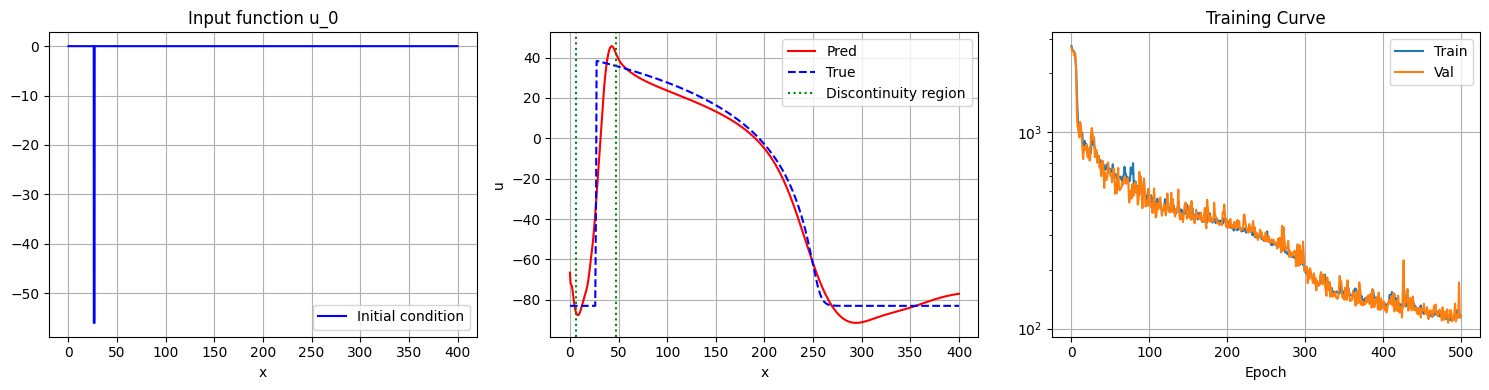

Total parameters: 929,957, trainable parameters: 929,957
L1 Loss (all points): 6.116, std: 1.900
L1 Loss (near discontinuity): 19.592, std: 3.335


In [13]:
# Load the trained Lifted-DeepONet model
checkpoint = torch.load("checkpoints/vanilla_deeponet_checkpoint.pt", map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

input_data_test, output_data_test, sharp_jump_test = input_data[test_idx], output_data[test_idx], sharp_jump_all[test_idx]

l1_loss_all, l1_loss_near_discon_all = error_analysis_dataset_test(model, input_data_test, output_data_test, t, sharp_jump_test, window_size=int(0.05 * Nt))
show_results(model, checkpoint, input_data_test, output_data_test, t, sharp_jump_test, sample_id=2)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}, trainable parameters: {trainable_params:,}")
print(f"L1 Loss (all points): {np.mean(l1_loss_all):.3f}, std: {np.std(l1_loss_all):.3f}")
print(f"L1 Loss (near discontinuity): {np.mean(l1_loss_near_discon_all):.3f}, std: {np.std(l1_loss_near_discon_all):.3f}")